# Exercises

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
from scipy.optimize import minimize

sns.set_theme(context='notebook',style='white',font_scale=1.5,
              rc = {'axes.spines.top':False,'axes.spines.right':False})


## Exercise 1
---
Determine the effect of stimulus sequence duration on RF estimates. To do this, repeat the above steps for different durations (5 s, 10 s, 20 s, 40 s, 80 s, 160 s, 320 s, 640 s). Compute the Pearson correlation between true and estimated RFs for each duration to quantify the accuracy of the estimator. The Pearson correlation $\mathrm{cc}$ is defined as
$$
\mathrm{cc} = \frac{\mathbf{k}_\mathrm{true}^T \hat{\mathbf{k}}}{\lVert \mathbf{k}_\mathrm{true} \rVert \lVert \hat{\mathbf{k}} \rVert}
$$
where $\lVert \cdot \rVert$ is the L2-norm (vector length).
As the response generation process is stochastic, compute the average correlation across 10 realizations for the same duration and plot the average correlation as a function of duration. How is the recording duration related to the ability to recover the true RF?

To do this, we have to do the same but create a loop for the code, see below. Just as in the lecture notes, we generated a stimulus, simulated the spiking responses using the linear-nonlinear Poisson model, estimated the RF and computed the Pearson's correlation between the real and estimated RF. What we see in the plot is that the average Pearson's correlation increases when we increase the stimulus duration. This makes sense and also correspond to what was said in the lecture, as with longer recordings, the model has access to more data, which improves the signal-to-noise ratio when estimating the RF. This allows the model to estimate a better fit for the RF.



Text(0, 0.5, 'y')

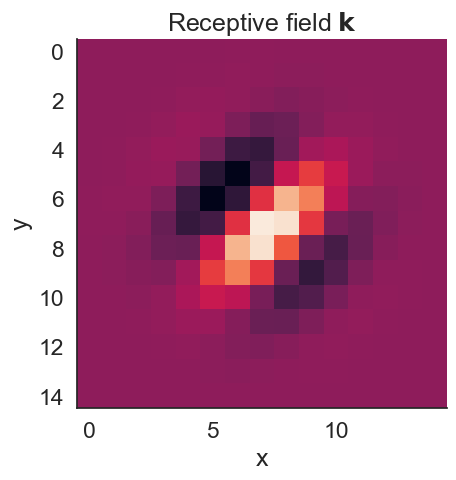

In [18]:
size = vf_size # size in pixel of our receptive field
mu = (8, 8) # center of the gabor pathc
sigma = (4,4) #size of the gabor patch
angle = 45 # orientation of the gabor patch
frequency = .085 # spatial frequency of the gabor patch
phase = 0 # pahse of the gabor pathc


xx, yy = np.meshgrid(1. + np.arange(size[0]),
                         1. + np.arange(size[1]))

# Gaussian envelope
G = np.exp(- np.power(xx - mu[0], 2) / (2. * sigma[0])
            - np.power(yy - mu[1], 2) / (2. * sigma[1]))

# spatial modulation
phi = np.deg2rad(angle)
xxr = xx * np.cos(phi)
yyr = yy * np.sin(phi)
xyr = (xxr + yyr) * 2. * np.pi * 2. * frequency
Sn = np.cos(xyr + phase)

K = G * Sn
K /= np.amax(np.abs(K))

plt.imshow(K)
plt.title(r'Receptive field $\bf{k}$')
plt.xlabel('x')
plt.ylabel('y')

In [19]:
dt = 0.1
std_dev = 1
vf_size = (15,15)
spike_rate = 5  # average target firing rate
durations = [5, 10, 20, 40, 80, 160, 320, 640]
n_repeats = 10  # trials per duration

# --- True RF ---
np.random.seed(0)
K = np.random.randn(*vf_size)
K_flat_true = K.ravel()

# --- Poisson spike generator ---
def generate_inhomogeneous_poisson_spikes(lamda, dt):
    n_bins = lamda.shape[0]
    bins = np.arange(n_bins + 1) * dt
    lamda_max = np.max(lamda)
    poisson_numbers = np.random.poisson(lamda_max, size=n_bins)

    spike_times = []
    prob = lamda / lamda_max
    for i in range(n_bins):
        n = np.sum(np.random.rand(poisson_numbers[i]) < prob[i])
        n_s = int(round(n * dt))
        ts = bins[i] + np.random.rand(n_s) * dt
        spike_times.extend(ts)
    return np.asarray(spike_times)

# --- Cost and gradient for GLM fitting ---
def cost(k, spike_counts, S, alpha=1):
    ks = np.dot(k, S.T)
    lamda = np.exp(ks)
    return -np.dot(spike_counts, ks) + dt * np.sum(lamda)

def grad(k, spike_counts, S):
    ks = np.dot(k, S.T)
    lamda = np.exp(ks)
    return -np.dot(S.T, spike_counts - dt * lamda)

# --- Duration sweep ---
avg_corrs = []

for duration in durations:
    corrs = []
    for _ in range(n_repeats):
        n_bins = round(duration / dt)
        
        # Stimulus
        S = std_dev * np.random.randn(n_bins, vf_size[0], vf_size[1])
        S_flat = S.reshape(n_bins, -1)
        S_flat = np.hstack((S_flat, np.ones((n_bins, 1))))  # add bias

        # Linear stage
        K_flat = np.hstack((K_flat_true, 0.0))  # add offset
        ks = np.dot(K_flat, S_flat.T)

        # Nonlinear stage
        lamda = np.exp(ks)
        expected_rate = np.sum(lamda * dt) / duration
        lamda *= (spike_rate / expected_rate)

        # Generate spikes
        spike_times = generate_inhomogeneous_poisson_spikes(lamda, dt)
        spike_counts = np.histogram(spike_times, bins=np.arange(n_bins + 1) * dt)[0]

        # Estimate RF
        k_STA = np.inner(S_flat.T, spike_counts) / np.sum(spike_counts)
        res = minimize(fun=cost, x0=k_STA / 10, args=(spike_counts, S_flat),
                       method='Newton-CG', jac=grad)
        K_est = res.x

        # Pearson correlation
        cc = np.inner(K.ravel(), K_est[:-1]) / (
            np.linalg.norm(K.ravel()) * np.linalg.norm(K_est[:-1])
        )
        corrs.append(cc)

    avg_corr = np.mean(corrs)
    avg_corrs.append(avg_corr)
    print(f"Duration: {duration:>4}s | Avg Pearson Corr: {avg_corr:.3f}")


C:\Users\Beheerder\AppData\Local\Temp\ipykernel_22572\3526896195.py:37: RuntimeWarning: overflow encountered in exp
  lamda = np.exp(ks)


Duration:    5s | Avg Pearson Corr: 0.116
Duration:   10s | Avg Pearson Corr: 0.125
Duration:   20s | Avg Pearson Corr: 0.164


C:\Users\Beheerder\AppData\Local\Temp\ipykernel_22572\3526896195.py:32: RuntimeWarning: overflow encountered in exp
  lamda = np.exp(ks)
C:\Users\Beheerder\AppData\Local\Temp\ipykernel_22572\3526896195.py:32: RuntimeWarning: overflow encountered in exp
  lamda = np.exp(ks)
C:\Users\Beheerder\AppData\Local\Temp\ipykernel_22572\3526896195.py:32: RuntimeWarning: overflow encountered in exp
  lamda = np.exp(ks)
C:\Users\Beheerder\AppData\Local\Temp\ipykernel_22572\3526896195.py:37: RuntimeWarning: overflow encountered in exp
  lamda = np.exp(ks)
C:\Users\Beheerder\AppData\Local\Temp\ipykernel_22572\3526896195.py:32: RuntimeWarning: overflow encountered in exp
  lamda = np.exp(ks)
C:\Users\Beheerder\AppData\Local\Temp\ipykernel_22572\3526896195.py:37: RuntimeWarning: overflow encountered in exp
  lamda = np.exp(ks)


Duration:   40s | Avg Pearson Corr: 0.189


C:\Users\Beheerder\AppData\Local\Temp\ipykernel_22572\3526896195.py:32: RuntimeWarning: overflow encountered in exp
  lamda = np.exp(ks)
C:\Users\Beheerder\AppData\Local\Temp\ipykernel_22572\3526896195.py:32: RuntimeWarning: overflow encountered in exp
  lamda = np.exp(ks)
C:\Users\Beheerder\AppData\Local\Temp\ipykernel_22572\3526896195.py:37: RuntimeWarning: overflow encountered in exp
  lamda = np.exp(ks)
C:\Users\Beheerder\AppData\Local\Temp\ipykernel_22572\3526896195.py:32: RuntimeWarning: overflow encountered in exp
  lamda = np.exp(ks)
C:\Users\Beheerder\AppData\Local\Temp\ipykernel_22572\3526896195.py:37: RuntimeWarning: overflow encountered in exp
  lamda = np.exp(ks)


Duration:   80s | Avg Pearson Corr: 0.240


C:\Users\Beheerder\AppData\Local\Temp\ipykernel_22572\3526896195.py:32: RuntimeWarning: overflow encountered in exp
  lamda = np.exp(ks)
C:\Users\Beheerder\AppData\Local\Temp\ipykernel_22572\3526896195.py:37: RuntimeWarning: overflow encountered in exp
  lamda = np.exp(ks)


Duration:  160s | Avg Pearson Corr: 0.292
Duration:  320s | Avg Pearson Corr: 0.398


C:\Users\Beheerder\AppData\Local\Temp\ipykernel_22572\3526896195.py:37: RuntimeWarning: overflow encountered in exp
  lamda = np.exp(ks)


Duration:  640s | Avg Pearson Corr: 0.379


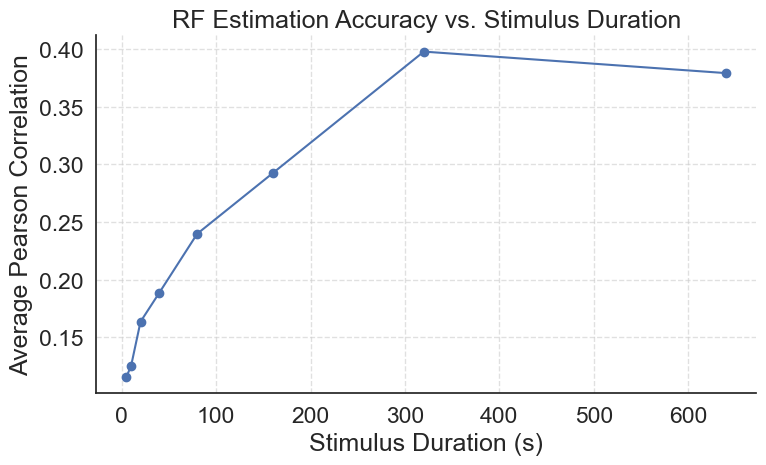

In [20]:
# --- Plotting ---
plt.figure(figsize=(8,5))
plt.plot(durations, avg_corrs, marker='o')
plt.xlabel('Stimulus Duration (s)')
plt.ylabel('Average Pearson Correlation')
plt.title('RF Estimation Accuracy vs. Stimulus Duration')
plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## Exercise 2
---

Determine the effect of response noise ($\sigma^2$) on RF estimates. Try different value for the noise variance in the simulations, e.g., 0, 2, 4, 6, 8, and 10 for a duration of 100 s. As in the previous excercise, repeatedly estimate RF parameters for each condition (10 times) but this time also plot the standard deviation of the correlations across the different runs for each condition.

In [21]:
from sklearn.linear_model import Ridge
from scipy.stats import pearsonr


noise_vars = [0, 2, 4, 6, 8, 10]
duration = 100 
dt = 0.1
n_bins = int(duration / dt)
vf_size = (15, 15)
std_dev = 1
n_repeats = 10

# Ground truth RF
np.random.seed(0)
K_true = np.random.randn(*vf_size).ravel()

# Store results
mean_corrs = []
std_corrs = []

for sigma2 in noise_vars:
    corrs = []

    for _ in range(n_repeats):
        # Stimulus
        S = std_dev * np.random.randn(n_bins, vf_size[0]*vf_size[1])
        S /= np.std(S)  # normalize stimulus

        # Linear response
        ks = S @ K_true

        # Add Gaussian noise
        noise = np.random.normal(0, np.sqrt(sigma2), size=n_bins)
        y = ks + noise

        # Fit using ridge regression (Linear Gaussian)
        model = Ridge(alpha=1.0)
        model.fit(S, y)
        K_est = model.coef_

        # Pearson correlation
        cc, _ = pearsonr(K_true, K_est)
        corrs.append(cc)

    # Store stats
    mean_corrs.append(np.mean(corrs))
    std_corrs.append(np.std(corrs))

    print(f"Noise σ² = {sigma2}: mean cc = {np.mean(corrs):.3f}, std = {np.std(corrs):.3f}")


Noise σ² = 0: mean cc = 1.000, std = 0.000
Noise σ² = 2: mean cc = 0.999, std = 0.000
Noise σ² = 4: mean cc = 0.997, std = 0.000
Noise σ² = 6: mean cc = 0.996, std = 0.000
Noise σ² = 8: mean cc = 0.995, std = 0.000
Noise σ² = 10: mean cc = 0.994, std = 0.001


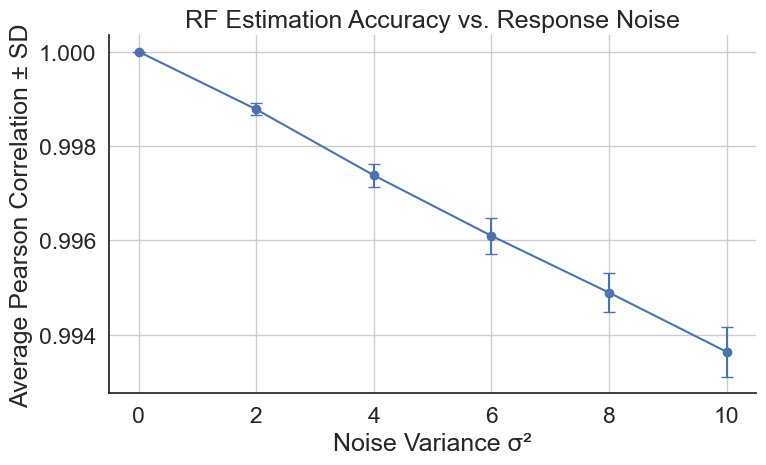

In [22]:
plt.figure(figsize=(8,5))
plt.errorbar(noise_vars, mean_corrs, yerr=std_corrs, fmt='-o', capsize=4)
plt.xlabel('Noise Variance σ²')
plt.ylabel('Average Pearson Correlation ± SD')
plt.title('RF Estimation Accuracy vs. Response Noise')
plt.grid(True)
plt.tight_layout()
plt.show()

## Exercise 3
---
Look at the analytical derivation of the log-likelihood for the poisson GLM.
Which of the terms are required for maximizing the likelihood with respect to $\mathbf{k}$ and which terms can be ignored? **Note:** due to the independence of spikes in the different bins, the likelihood can be written as $P(R | S, \mathbf{k}) = \prod_t^T P(r_t | \mathbf{s}_t, \mathbf{k})$. The log turns the product into a sum which makes life much easier. 

When maximizing the log-likelihoood for the poisson GLM, you can ignore the terms that don't depend on k (the variable that has to be optimized). 

For a Linear-Nonlinear Poisson (LNP) model with an exponential nonlinearity  
$\lambda_t = \exp(\mathbf{k}^\top \mathbf{s}_t)$,  
the log-likelihood for a single observation is:

$$
\log P(r_t | \lambda_t) = r_t \log \lambda_t + r_t \log \Delta - \log r_t! - \lambda_t \Delta
$$

Summing over all time bins, the full log-likelihood becomes:

$$
\log P(R | \lambda) = \sum_t \left[ r_t \log \lambda_t + r_t \log \Delta - \log r_t! - \lambda_t \Delta \right]
$$

When optimizing with respect to $\mathbf{k}$, we can ignore constant terms  
$r_t \log \Delta$ and $\log r_t!$, leaving:

$$
\mathcal{L}(\mathbf{k}) = \sum_t \left[ r_t \mathbf{k}^\top \mathbf{s}_t - \Delta \exp(\mathbf{k}^\top \mathbf{s}_t) \right]
$$

The gradient of the log-likelihood with respect to $\mathbf{k}$ is:

$$
\frac{\partial \log P}{\partial \mathbf{k}} = \sum_t r_t \mathbf{s}_t - \Delta \sum_t \lambda_t \mathbf{s}_t
$$


## Exercise 4
---
Explore the effect of the data duration and the firing rate on the goodness of fit of the Poisson GLM.

A - Generate data with durations of 10,20,50,100 and 200 seconds. Fit the model on each dataset and plot the fitted parameters.
Use the pearson correlation as a proxy of the goodness of fit, and plot it as a function of the duration of the data.

B - Fix the duration to 100s, and change the average firing rate of the simulation. How does the fit perform for different firing rates? 

## Effect of duration

In [23]:
durations = [10, 20, 50, 100, 200]
n_trials = 10
fixed_spike_rate = 5  # Hz

pearson_corrs_duration = []

for duration in durations:
    trial_corrs = []
    n_bins = int(duration / dt)
    
    for _ in range(n_trials):
        # Generate stimulus
        S = std_dev * np.random.randn(n_bins, vf_size[0], vf_size[1])
        S_flat = S.reshape(n_bins, -1)
        S_flat = np.hstack((S_flat, np.ones((n_bins, 1))))  # add bias
        
        # Flatten true RF with bias term
        K_flat = np.append(K.ravel(), 0.5)  # bias term for offset
        
        # Linear drive
        ks = S_flat @ K_flat
        
        # Nonlinear rate
        lamda = np.exp(ks)
        expected_rate = np.sum(lamda * dt) / duration
        lamda *= (fixed_spike_rate / expected_rate)
        
        # Generate spikes
        spike_times = generate_inhomogeneous_poisson_spikes(lamda, dt)
        spike_counts = np.histogram(spike_times, bins=np.arange(n_bins+1)*dt)[0]
        
        # Fit GLM
        k_sta = np.inner(S_flat.T, spike_counts) / np.sum(spike_counts)
        res = minimize(fun=cost, x0=k_sta / 10, args=(spike_counts, S_flat, dt),
                       method='Newton-CG', jac=grad)
        K_est = res.x
        
        # Pearson correlation (ignore bias term)
        corr = np.corrcoef(K.ravel(), K_est[:-1])[0,1]
        trial_corrs.append(corr)
    
    pearson_corrs_duration.append(np.mean(trial_corrs))



TypeError: grad() takes 3 positional arguments but 4 were given

In [ ]:
# Plot results
plt.figure(figsize=(6,4))
plt.plot(durations, pearson_corrs_duration, marker='o')
plt.xlabel('Stimulus Duration (s)')
plt.ylabel('Average Pearson Correlation')
plt.title('Effect of Stimulus Duration on RF Estimation')
plt.grid(True)
plt.show()

## Effect of firing rate

In [24]:
firing_rates = [1, 5, 10, 20, 40]
fixed_duration = 100
n_bins = int(fixed_duration / dt)
n_trials = 10

pearson_corrs_rate = []

for spike_rate in firing_rates:
    trial_corrs = []
    
    for _ in range(n_trials):
        # Generate stimulus
        S = std_dev * np.random.randn(n_bins, vf_size[0], vf_size[1])
        S_flat = S.reshape(n_bins, -1)
        S_flat = np.hstack((S_flat, np.ones((n_bins, 1))))  # add bias
        
        K_flat = np.append(K.ravel(), 0.5)  # bias term
        
        ks = S_flat @ K_flat
        lamda = np.exp(ks)
        expected_rate = np.sum(lamda * dt) / fixed_duration
        lamda *= (spike_rate / expected_rate)
        
        spike_times = generate_inhomogeneous_poisson_spikes(lamda, dt)
        spike_counts = np.histogram(spike_times, bins=np.arange(n_bins+1)*dt)[0]
        
        k_sta = np.inner(S_flat.T, spike_counts) / np.sum(spike_counts)
        res = minimize(fun=cost, x0=k_sta / 10, args=(spike_counts, S_flat, dt),
                       method='Newton-CG', jac=grad)
        K_est = res.x
        
        corr = np.corrcoef(K.ravel(), K_est[:-1])[0,1]
        trial_corrs.append(corr)
    
    pearson_corrs_rate.append(np.mean(trial_corrs))


TypeError: grad() takes 3 positional arguments but 4 were given

In [ ]:
plt.figure(figsize=(6,4))
plt.plot(firing_rates, pearson_corrs_rate, marker='o')
plt.xlabel('Firing Rate (Hz)')
plt.ylabel('Average Pearson Correlation')
plt.title('Effect of Firing Rate on RF Estimation')
plt.grid(True)
plt.show()